## Install required packages

The project uses a few standard Python libraries for data analysis, plotting, model building, and saving the final pipeline for Streamlit deployment.

In [ ]:
!pip install numpy pandas matplotlib seaborn scipy scikit-learn xgboost joblib

# Heart Disease Prediction

This notebook presents a simple machine learning workflow for heart disease prediction. The flow covers data understanding, cleaning, exploratory analysis, feature handling, model comparison, and model saving for Streamlit deployment.

## Understanding the data

The dataset contains patient details such as age, sex, chest pain type, blood pressure, cholesterol, maximum heart rate, and other medical measurements.

The target column is binary. `1` means heart disease is present and `0` means heart disease is not present.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from joblib import dump

from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, cross_val_score, ShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Loading the data

The CSV file is loaded first. After that, the first few rows are checked to confirm that the file is read properly.

In [2]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Data analysis

This section checks the shape of the dataset, summary statistics, missing values, and duplicate rows. It gives a quick idea of the data quality before cleaning.

In [6]:
print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
print('\nInfo:')
df.info()
print('\nDescribe:')
print(df.describe())
print('\nMissing values:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

Shape: (303, 14)

Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

Describe:
              age         sex          cp    trestb

## Missing value handling

The dataset does not contain missing values in the current file. A KNN imputer check is still included so the workflow is ready if a new file contains missing entries later.

In [7]:
missing_total = df.isnull().sum().sum()
if missing_total > 0:
    imputer = KNNImputer(n_neighbors=5)
    feature_cols = [col for col in df.columns if col != 'target']
    df[feature_cols] = imputer.fit_transform(df[feature_cols])
    print('Missing values were filled using KNN imputer.')
else:
    print('No missing values were found, so no imputation was needed.')

No missing values were found, so no imputation was needed.


## Exploratory data analysis

This section reviews the target distribution and the spread of important features. The plots help show how the data behaves before model building.

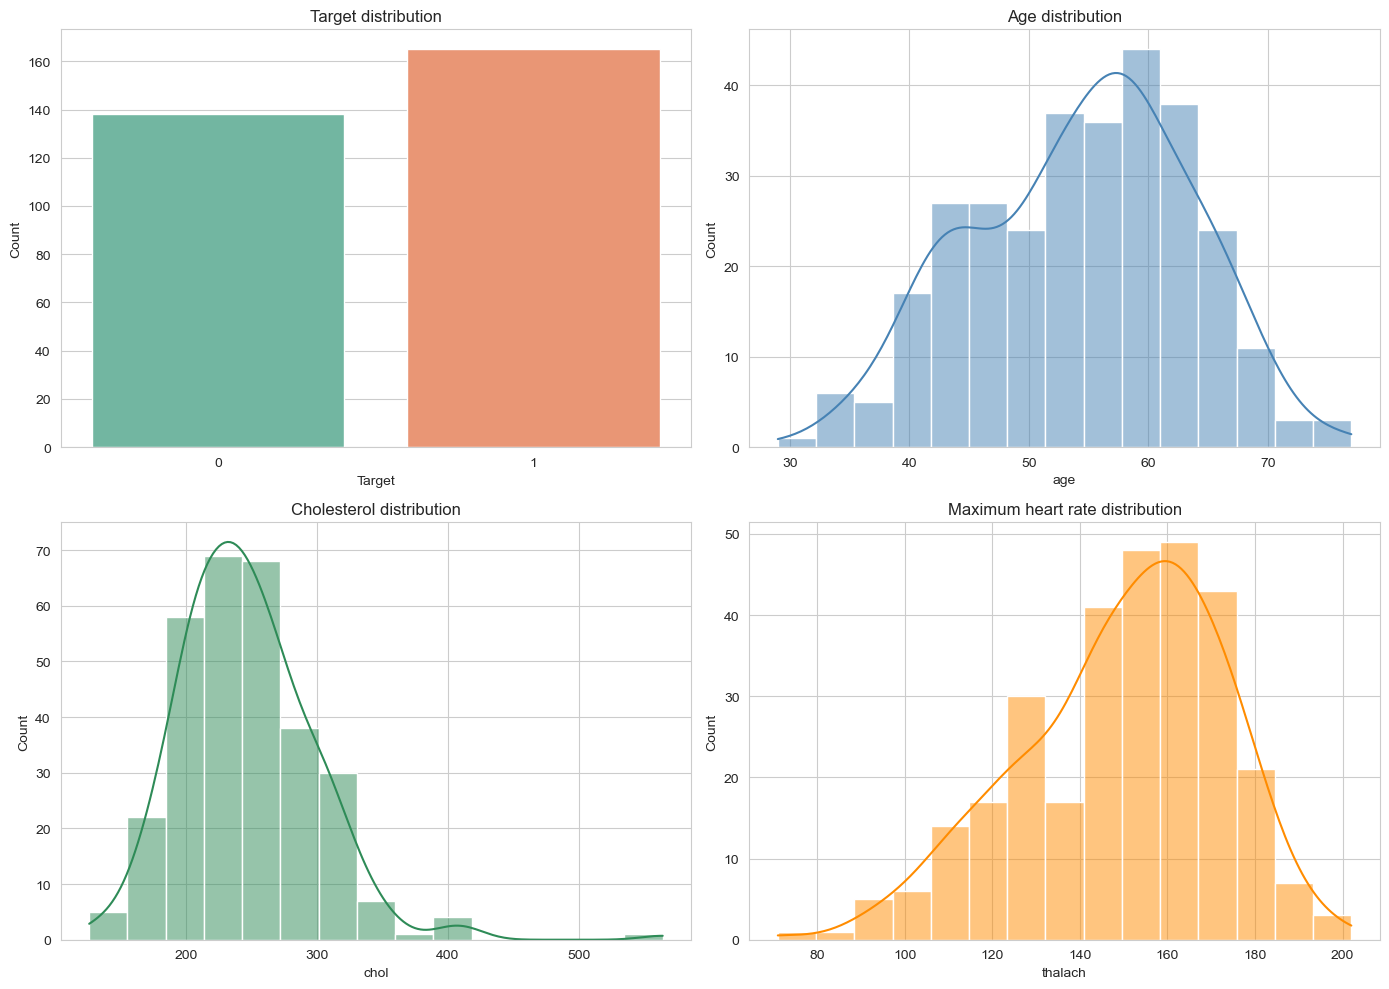

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x='target', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Target distribution')
axes[0, 0].set_xlabel('Target')
axes[0, 0].set_ylabel('Count')

sns.histplot(df['age'], bins=15, kde=True, ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Age distribution')

sns.histplot(df['chol'], bins=15, kde=True, ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Cholesterol distribution')

sns.histplot(df['thalach'], bins=15, kde=True, ax=axes[1, 1], color='darkorange')
axes[1, 1].set_title('Maximum heart rate distribution')

plt.tight_layout()
plt.show()

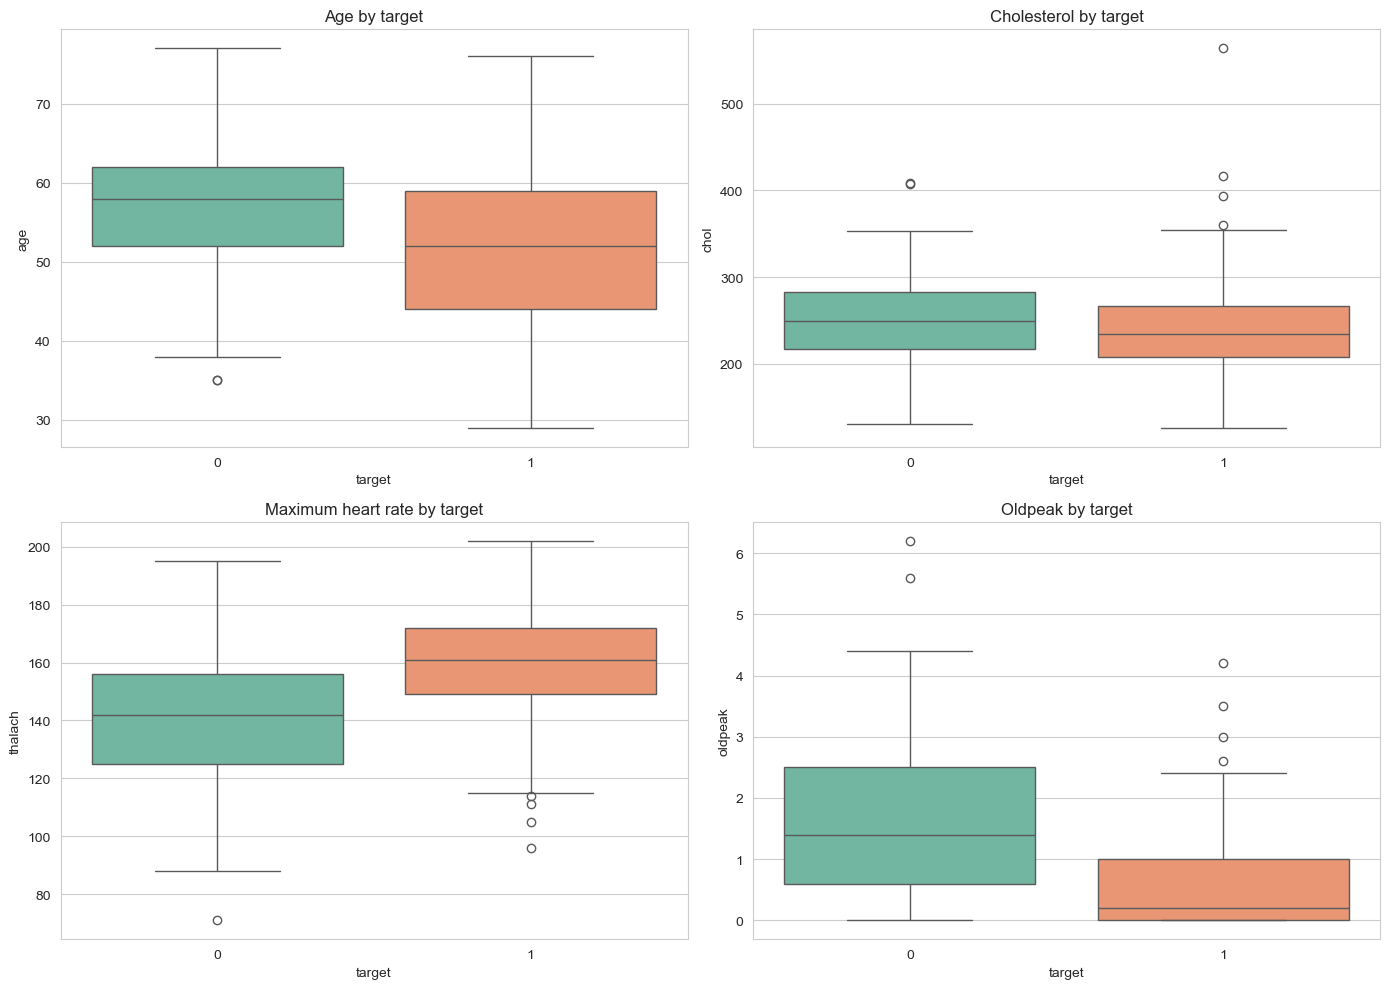

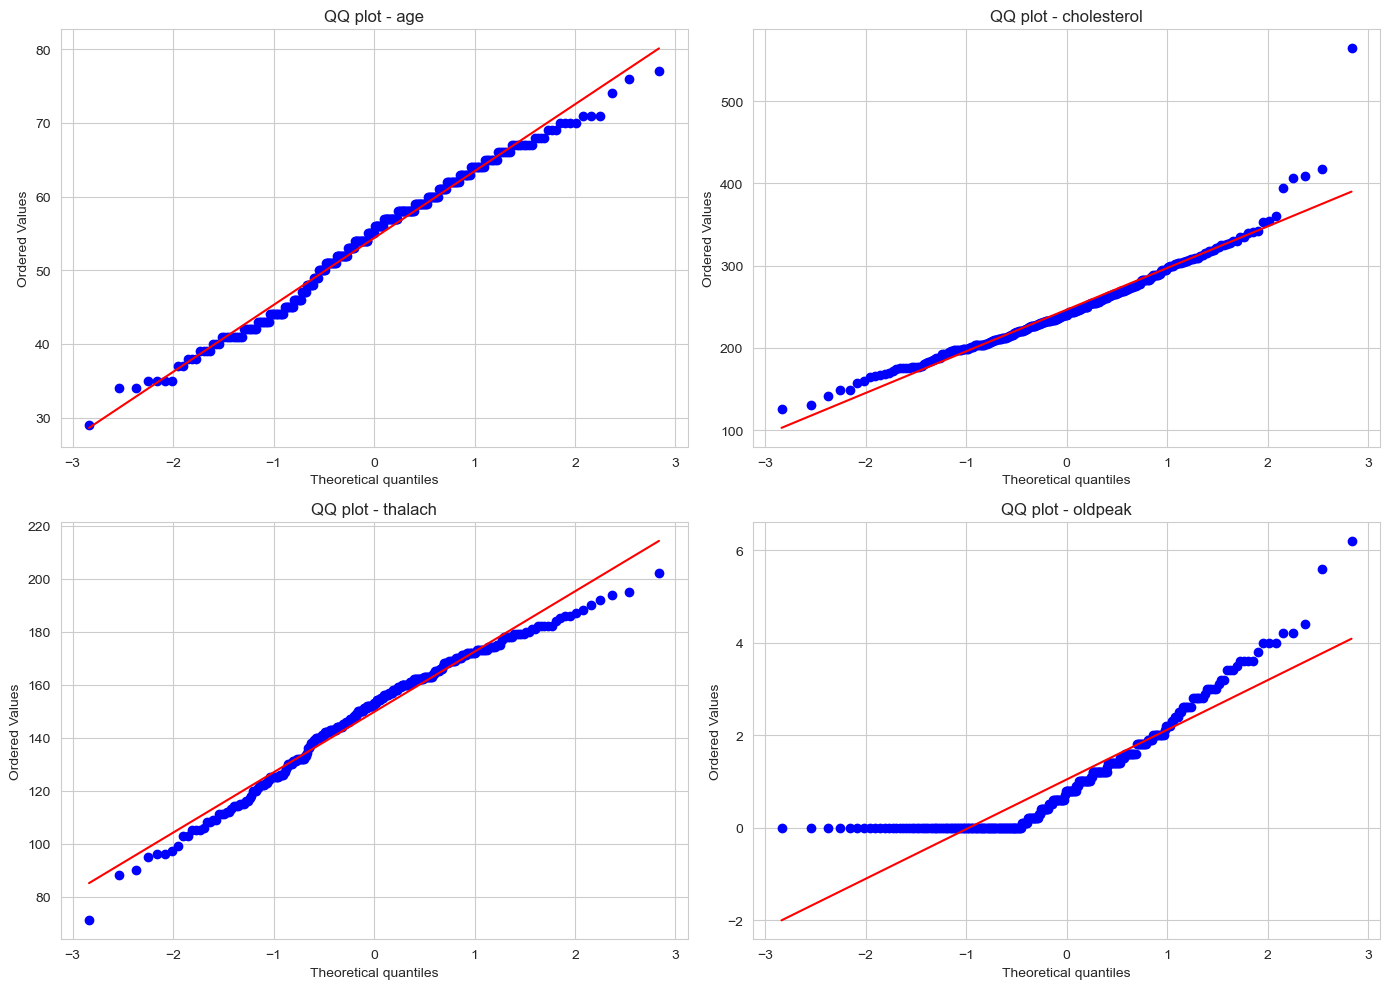

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='target', y='age', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Age by target')

sns.boxplot(data=df, x='target', y='chol', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Cholesterol by target')

sns.boxplot(data=df, x='target', y='thalach', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Maximum heart rate by target')

sns.boxplot(data=df, x='target', y='oldpeak', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Oldpeak by target')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
stats.probplot(df['age'], dist='norm', plot=axes[0, 0])
axes[0, 0].set_title('QQ plot - age')
stats.probplot(df['chol'], dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('QQ plot - cholesterol')
stats.probplot(df['thalach'], dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('QQ plot - thalach')
stats.probplot(df['oldpeak'], dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('QQ plot - oldpeak')
plt.tight_layout()
plt.show()

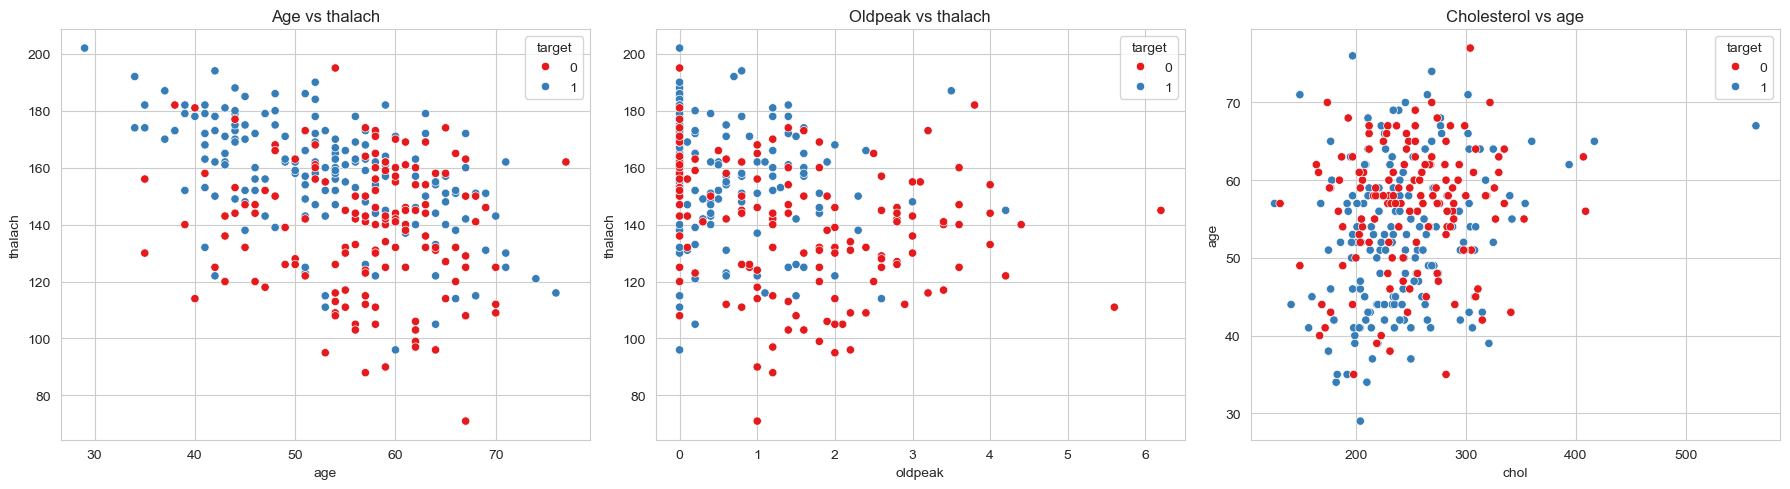

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x='age', y='thalach', hue='target', palette='Set1', ax=axes[0])
axes[0].set_title('Age vs thalach')

sns.scatterplot(data=df, x='oldpeak', y='thalach', hue='target', palette='Set1', ax=axes[1])
axes[1].set_title('Oldpeak vs thalach')

sns.scatterplot(data=df, x='chol', y='age', hue='target', palette='Set1', ax=axes[2])
axes[2].set_title('Cholesterol vs age')

plt.tight_layout()
plt.show()

## Correlation

Spearman correlation is used because it is useful for checking monotonic relationships. Highly correlated columns are removed so the model stays simpler and less repetitive.

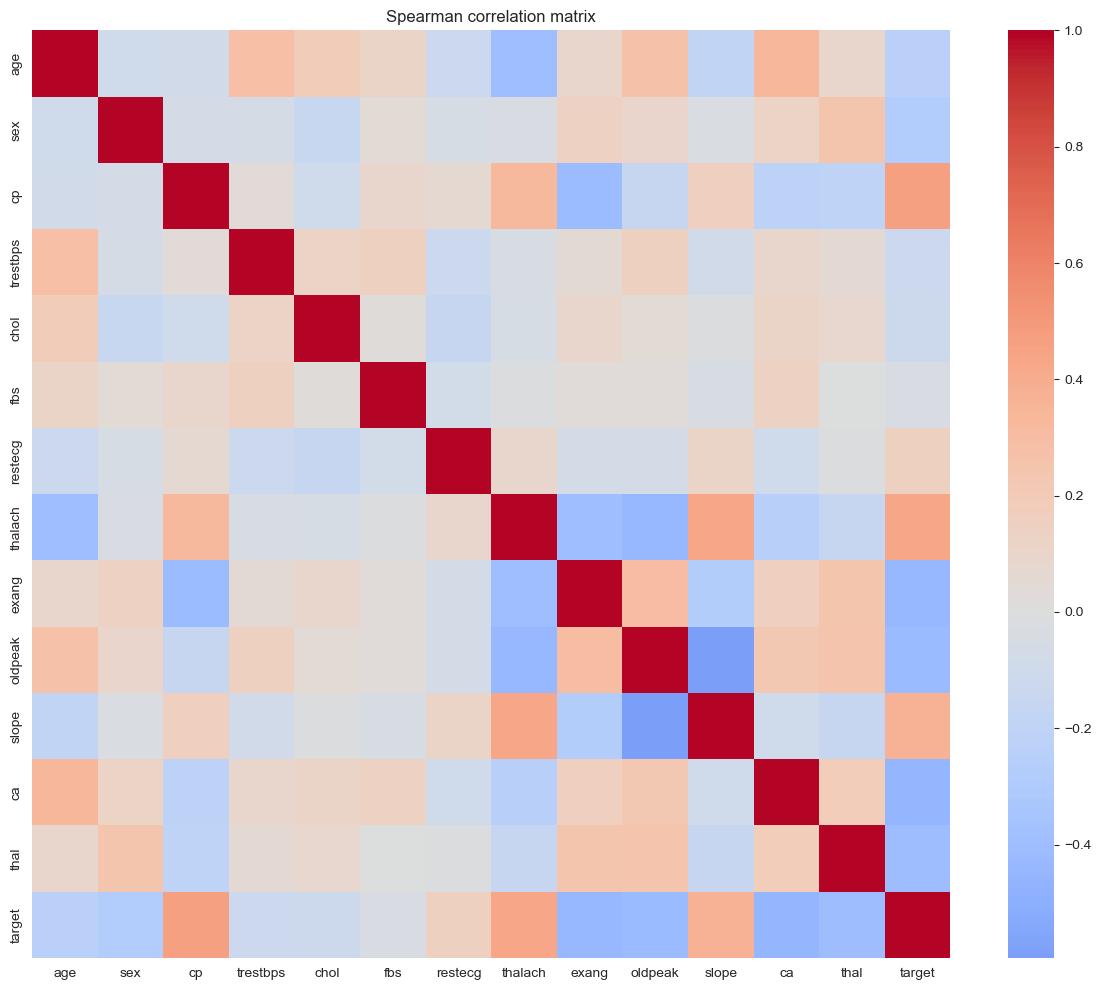

Highly correlated columns to drop: []
Shape after correlation filtering: (303, 14)


In [12]:
spearman_corr = df.corr(method='spearman', numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(spearman_corr, cmap='coolwarm', center=0, annot=False)
plt.title('Spearman correlation matrix')
plt.tight_layout()
plt.show()

threshold = 0.80
upper_triangle = spearman_corr.abs().where(np.triu(np.ones(spearman_corr.shape), k=1).astype(bool))
high_corr_columns = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]
print('Highly correlated columns to drop:', high_corr_columns)

df_corr = df.drop(columns=high_corr_columns).copy()
print('Shape after correlation filtering:', df_corr.shape)

## Data cleaning

Outliers are checked using the IQR method on the main continuous columns. Boxplots are shown again after cleaning to verify that the extreme values were reduced.

Rows before IQR cleaning: 303
Rows after IQR cleaning: 284
Rows removed: 19


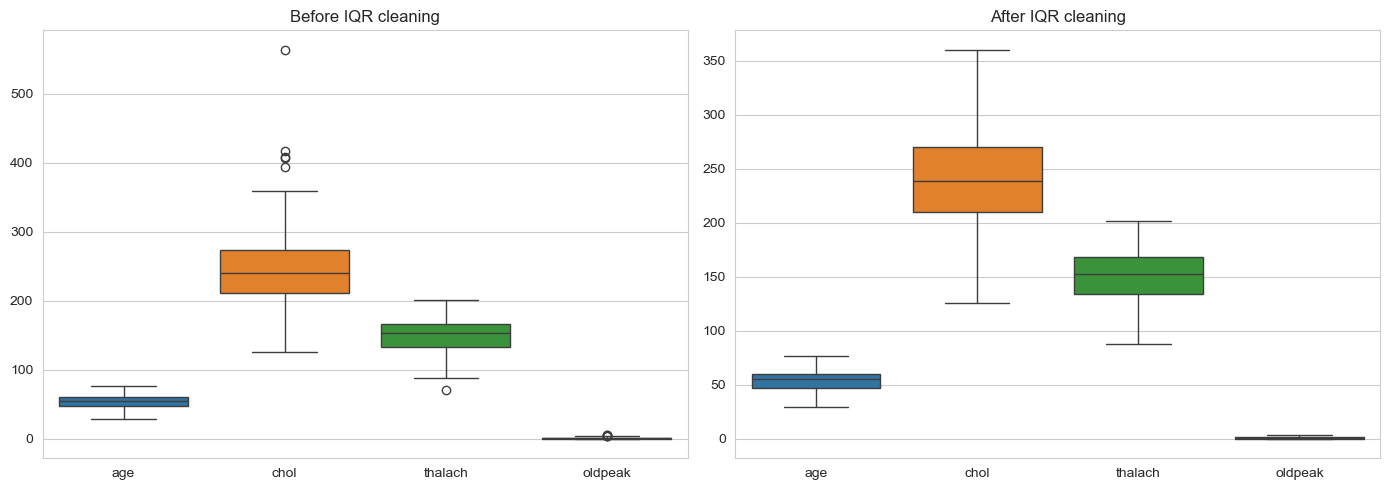

In [13]:
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df_clean = df_corr.copy()
before_rows = df_clean.shape[0]

for column in continuous_cols:
    if column in df_clean.columns:
        q1 = df_clean[column].quantile(0.25)
        q3 = df_clean[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        df_clean = df_clean[(df_clean[column] >= lower_bound) & (df_clean[column] <= upper_bound)]

after_rows = df_clean.shape[0]
print('Rows before IQR cleaning:', before_rows)
print('Rows after IQR cleaning:', after_rows)
print('Rows removed:', before_rows - after_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_corr[['age', 'chol', 'thalach', 'oldpeak']], ax=axes[0])
axes[0].set_title('Before IQR cleaning')
sns.boxplot(data=df_clean[['age', 'chol', 'thalach', 'oldpeak']], ax=axes[1])
axes[1].set_title('After IQR cleaning')
plt.tight_layout()
plt.show()

## Feature engineering

The dataset is already numeric, so extra label encoding is not required. Weak target features are removed after checking their Spearman relation with the target.

In [14]:
X_full = df_clean.drop('target', axis=1)
y = df_clean['target']

target_corr = X_full.apply(lambda col: col.corr(y, method='spearman')).abs().sort_values(ascending=False)
print('Spearman correlation with target:')
print(target_corr)

selected_features = target_corr[target_corr >= 0.10].index.tolist()
if len(selected_features) == 0:
    selected_features = X_full.columns.tolist()

print('Selected features:')
print(selected_features)

X = X_full[selected_features].copy()
print('Shape after feature selection:', X.shape)

Spearman correlation with target:
ca          0.455106
cp          0.445227
exang       0.432780
thalach     0.427529
oldpeak     0.417119
thal        0.409417
slope       0.355780
sex         0.316165
age         0.244670
restecg     0.177481
chol        0.119318
trestbps    0.098666
fbs         0.028433
dtype: float64
Selected features:
['ca', 'cp', 'exang', 'thalach', 'oldpeak', 'thal', 'slope', 'sex', 'age', 'restecg', 'chol']
Shape after feature selection: (284, 11)


## Model building

The target is binary, so classification models are used instead of regression models. Logistic Regression, Decision Tree, Random Forest, and XGBoost are compared. Standard scaling is kept inside the pipeline so the notebook stays ready for deployment.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000))
    ]),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('model', XGBClassifier(
            random_state=42,
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            eval_metric='logloss'
        ))
    ])
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions),
        'Recall': recall_score(y_test, predictions),
        'F1 Score': f1_score(y_test, predictions),
        'ROC AUC': roc_auc_score(y_test, model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_test))
    })

results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
3,XGBoost,0.894737,0.842105,1.0000,0.914286,0.93000
1,Decision Tree,0.859649,0.833333,0.9375,0.882353,0.84875
2,Random Forest,0.842105,0.780488,1.0000,0.876712,0.90500
0,Logistic Regression,0.824561,0.789474,0.9375,0.857143,0.88875


## Cross validation

ShuffleSplit is used with 10 splits to check whether the selected model is stable across different train-test splits. This gives a simple check on model consistency.

In [16]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
shuffle_split = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
cv_scores = cross_val_score(best_model, X, y, cv=shuffle_split, scoring='accuracy')
print('Best model:', best_model_name)
print('Cross validation accuracy scores:', cv_scores)
print('Mean cross validation accuracy:', round(cv_scores.mean(), 4))

Best model: XGBoost
Cross validation accuracy scores: [0.8245614  0.84210526 0.8245614  0.87719298 0.78947368 0.78947368
 0.80701754 0.84210526 0.80701754 0.84210526]
Mean cross validation accuracy: 0.8246


## Final model and saving the pipeline

The best model is fitted again on the cleaned dataset and saved together with the selected features. This keeps the Streamlit app simple because the same object can be loaded directly for prediction.

Accuracy: 0.9649
Precision: 0.9412
Recall: 1.0
F1 score: 0.9697
ROC AUC: 0.995

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        25
           1       0.94      1.00      0.97        32

    accuracy                           0.96        57
   macro avg       0.97      0.96      0.96        57
weighted avg       0.97      0.96      0.96        57



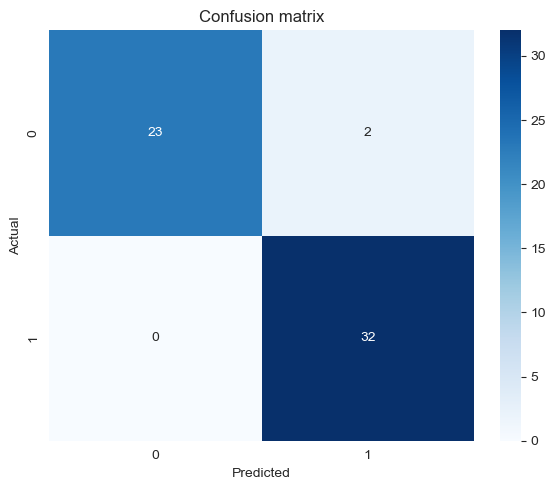

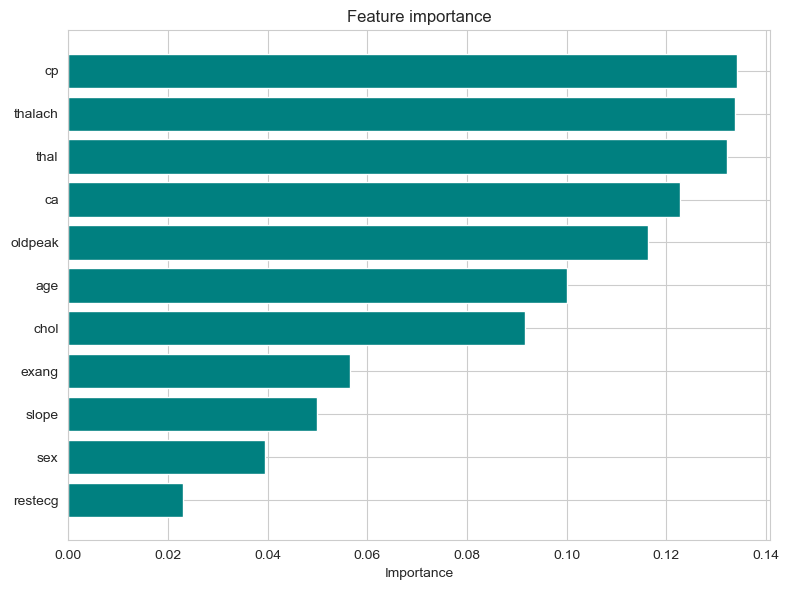

Saved file: heart_disease_pipeline.pkl


In [17]:
final_model = models[best_model_name]
final_model.fit(X, y)

test_predictions = final_model.predict(X_test)
print('Accuracy:', round(accuracy_score(y_test, test_predictions), 4))
print('Precision:', round(precision_score(y_test, test_predictions), 4))
print('Recall:', round(recall_score(y_test, test_predictions), 4))
print('F1 score:', round(f1_score(y_test, test_predictions), 4))
print('ROC AUC:', round(roc_auc_score(y_test, final_model.predict_proba(X_test)[:, 1] if hasattr(final_model, 'predict_proba') else final_model.decision_function(X_test)), 4))

print('\nClassification report:')
print(classification_report(y_test, test_predictions))

cm = confusion_matrix(y_test, test_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

feature_importance_model = RandomForestClassifier(n_estimators=300, random_state=42)
feature_importance_model.fit(X, y)
importance_values = pd.Series(feature_importance_model.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(8, 6))
plt.barh(importance_values.index, importance_values.values, color='teal')
plt.title('Feature importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

dump({'model': final_model, 'features': selected_features}, 'heart_disease_pipeline.pkl')
print('Saved file: heart_disease_pipeline.pkl')

## Conclusion

The project loaded the heart disease dataset, checked the data, handled missing values, explored the features, removed outliers, checked correlation, selected useful features, compared classification models, and saved the final pipeline for Streamlit deployment.